DATA Visualization

c:\Users\Wall-E\.conda\envs\vakkas\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] Belirtilen yordam bulunamadı'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9776908].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.

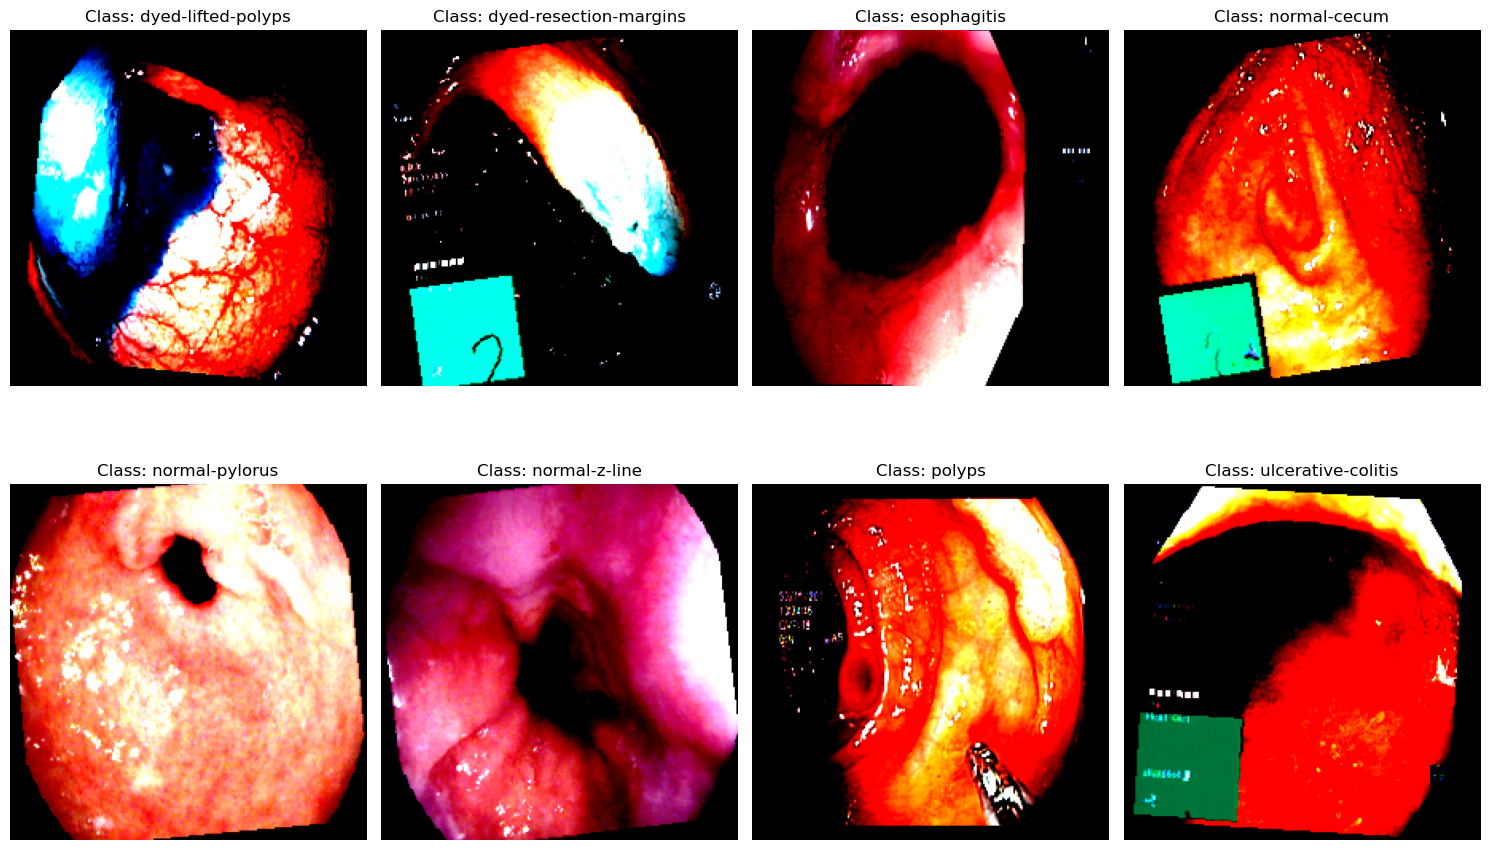

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import numpy as np
from torchvision import transforms 
from sklearn.model_selection import train_test_split
# Constants
DATASET_PATH = "kvasir-dataset-v2"  # Replace with your dataset path
IMG_SIZE = 224
BATCH_SIZE = 16
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data Augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Dataset
dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

# Dataset Split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.66, random_state=42)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

import matplotlib.pyplot as plt
import random

# Function to show one image from each class
def show_one_image_from_each_class(dataset, num_classes=8):
    class_to_idx = dataset.class_to_idx  # Mapping of class name to index
    idx_to_class = {v: k for k, v in class_to_idx.items()}  # Inverse mapping: index to class name

    # Prepare to plot images
    fig, axes = plt.subplots(2, 4, figsize=(15, 10))  # 2 rows, 4 columns
    axes = axes.flatten()  # Flatten to easily index the axes

    for i in range(num_classes):
        # Get all indices for the current class
        class_idx = i
        class_images = [idx for idx, label in enumerate(dataset.targets) if label == class_idx]
        
        # Randomly pick one image from this class
        random_image_idx = random.choice(class_images)
        image, label = dataset[random_image_idx]
        
        # Plot the image
        ax = axes[i]
        ax.imshow(image.permute(1, 2, 0).cpu())  # Convert from CxHxW to HxWxC for plt.imshow
        ax.axis('off')
        ax.set_title(f'Class: {idx_to_class[class_idx]}')
    
    plt.tight_layout()
    plt.show()

# Show one image from each class (8 classes in your dataset)
show_one_image_from_each_class(dataset, num_classes=8)

Hybrid Model: DenseNet201 + Swin Transformer

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from timm import create_model
import numpy as np
from sklearn.metrics import matthews_corrcoef

# Constants
DATASET_PATH = "kvasir-dataset-v2"  # Replace with your dataset path
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
LR = 0.001
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data Augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Dataset
dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

# Dataset Split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.66, random_state=42)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define Hybrid Model: DenseNet201 + Swin Transformer
class HybridDenseNetSwin(nn.Module):
    def __init__(self, num_classes):
        super(HybridDenseNetSwin, self).__init__()
        self.densenet = create_model('densenet201', pretrained=True, num_classes=num_classes)
        self.swin = create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)
        self.fc = nn.Sequential(
            nn.Linear(2 * num_classes, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        densenet_features = self.densenet(x)
        swin_features = self.swin(x)
        combined_features = torch.cat((densenet_features, swin_features), dim=1)
        return self.fc(combined_features)

# Initialize Model
DenseNetSwin = HybridDenseNetSwin(num_classes)
DenseNetSwin.to(DEVICE)

# Loss Function (Class-Balanced Loss)
class ClassBalancedLoss(nn.Module):
    def __init__(self, beta, num_classes):
        super(ClassBalancedLoss, self).__init__()
        self.beta = beta
        self.num_classes = num_classes

    def forward(self, logits, labels):
        class_counts = np.bincount(labels.cpu().numpy(), minlength=self.num_classes)
        effective_num = 1.0 - np.power(self.beta, class_counts)
        weights = (1.0 - self.beta) / (effective_num + 1e-8)
        weights = weights / np.sum(weights)  # Normalize weights
        weights = torch.tensor(weights, dtype=torch.float32).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return loss

loss_fn = ClassBalancedLoss(beta=0.999, num_classes=num_classes)
optimizer = optim.AdamW(DenseNetSwin.parameters(), lr=LR)

# Training Function
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

# Validation Function
def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    mcc = matthews_corrcoef(labels_list, preds_list)
    return total_loss / len(loader), 100.0 * correct / total, mcc

# Training Loop
best_mcc = 0
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}
for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(DenseNetSwin, train_loader, optimizer, loss_fn, DEVICE)
    val_loss, val_acc, val_mcc = validate_epoch(DenseNetSwin, val_loader, loss_fn, DEVICE)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val MCC: {val_mcc:.4f}")

    # Save the best model
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    # Save the best model
    if val_mcc > best_mcc:
        best_mcc = val_mcc
        torch.save(DenseNetSwin.state_dict(), "best_densenet_swin_model.pth")
        print(f"Best model saved with MCC: {val_mcc:.4f}")



c:\Users\Wall-E\.conda\envs\vakkas\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 1/25


Validation: 100%|██████████| 51/51 [00:17<00:00,  2.89it/s]


Train Loss: 0.9836, Train Acc: 53.39%
Val Loss: 1.1683, Val Acc: 54.41%, Val MCC: 0.4876
Best model saved with MCC: 0.4876
Epoch 2/25


Validation: 100%|██████████| 51/51 [00:17<00:00,  2.90it/s]


...

Train Loss: 0.2400, Train Acc: 89.48%
Val Loss: 0.2725, Val Acc: 91.18%, Val MCC: 0.8997
Best model saved with MCC: 0.8997
Epoch 24/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.00it/s]


Train Loss: 0.2455, Train Acc: 89.18%
Val Loss: 0.2428, Val Acc: 90.93%, Val MCC: 0.8968
Epoch 25/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.05it/s]

Train Loss: 0.2317, Train Acc: 89.71%
Val Loss: 0.2654, Val Acc: 89.09%, Val MCC: 0.8753


C:\Users\Wall-E\AppData\Local\Temp\ipykernel_20060\3642262386.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  DenseNetSwin.load_state_dict(torch.load("best_densenet_swin

Test Loss: 0.2639, Test Acc: 90.03%, Test MCC: 0.8866


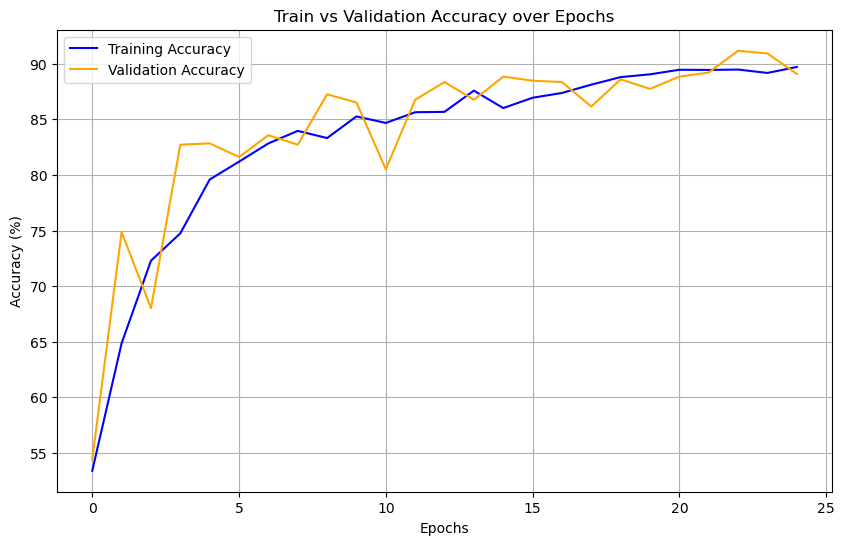

In [3]:
# Test the Model
DenseNetSwin.load_state_dict(torch.load("best_densenet_swin_model.pth"))
test_loss, test_acc, test_mcc = validate_epoch(DenseNetSwin, test_loader, loss_fn, DEVICE)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, Test MCC: {test_mcc:.4f}")
plt.figure(figsize=(10, 6))
plt.plot(history["train_acc"], label="Training Accuracy", color='blue')
plt.plot(history["val_acc"], label="Validation Accuracy", color='orange')
plt.title("Train vs Validation Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

Hybrid Model: ResNet50 + Swin Transformer 

Epoch 1/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.15it/s]


Train Loss: 0.9658, Train Acc: 56.36%
Val Loss: 0.6250, Val Acc: 76.47%, Val MCC: 0.7361
Best model saved with MCC: 0.7361
Epoch 2/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.13it/s]


Train Loss: 0.3969, Train Acc: 82.82%
Val Loss: 0.4581, Val Acc: 81.62%, Val MCC: 0.7968
Best model saved with MCC: 0.7968
Epoch 3/25


...

Train Loss: 0.0678, Train Acc: 97.18%
Val Loss: 0.3155, Val Acc: 90.20%, Val MCC: 0.8884
Epoch 25/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.12it/s]
C:\Users\Wall-E\AppData\Local\Temp\ipykernel_20060\360301825.py:155: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Train Loss: 0.0699, Train Acc: 97.20%
Val Loss: 0.3339, Val Acc: 89.95%, Val MCC: 0.8862


Validation: 100%|██████████| 99/99 [00:33<00:00,  2.99it/s]

Test Loss: 0.2808, Test Acc: 90.97%, Test MCC: 0.8971


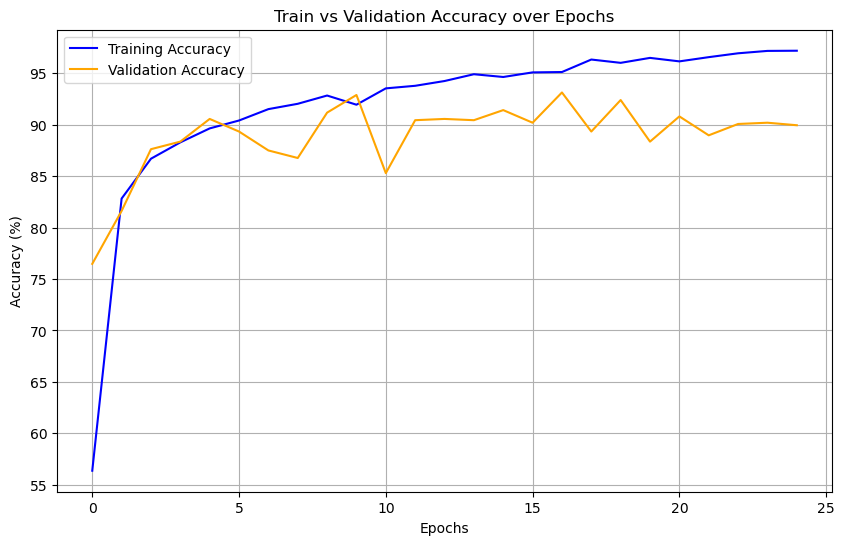

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from timm import create_model
import numpy as np
from sklearn.metrics import matthews_corrcoef, f1_score
from matplotlib import pyplot as plt

# Constants
DATASET_PATH = "kvasir-dataset-v2"  # Replace with your dataset path
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
LR = 0.001
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data Augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Dataset
dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

# Dataset Split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.66, random_state=42)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define Hybrid Model: ResNet50 + Swin Transformer
class HybridResNetSwin(nn.Module):
    def __init__(self, num_classes):
        super(HybridResNetSwin, self).__init__()
        self.resnet = create_model('resnet50', pretrained=True, num_classes=num_classes)
        self.swin = create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)
        self.fc = nn.Sequential(
            nn.Linear(2 * num_classes, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        resnet_features = self.resnet(x)
        swin_features = self.swin(x)
        combined_features = torch.cat((resnet_features, swin_features), dim=1)
        return self.fc(combined_features)

# Initialize Model
ResNetSwin = HybridResNetSwin(num_classes)
ResNetSwin.to(DEVICE)

# Loss Function (Class-Balanced Loss)
class ClassBalancedLoss(nn.Module):
    def __init__(self, beta, num_classes):
        super(ClassBalancedLoss, self).__init__()
        self.beta = beta
        self.num_classes = num_classes
        
    def forward(self, logits, labels):
        class_counts = np.bincount(labels.cpu().numpy(), minlength=self.num_classes)
        effective_num = 1.0 - np.power(self.beta, class_counts)
        weights = (1.0 - self.beta) / (effective_num + 1e-8)
        weights = weights / np.sum(weights)  # Normalize weights
        weights = torch.tensor(weights, dtype=torch.float32).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return loss

loss_fn = ClassBalancedLoss(beta=0.999, num_classes=num_classes)
optimizer = optim.AdamW(ResNetSwin.parameters(), lr=LR)

# Training Function
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

# Validation Function
def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    mcc = matthews_corrcoef(labels_list, preds_list)
    #f1 = f1_score(labels_list, preds_list, average="weighted")  # Eklenen F1-score
    return total_loss / len(loader), 100.0 * correct / total, mcc  # 4 değer döndürülüyor

# Training Loop
best_mcc = 0
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}
for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(ResNetSwin, train_loader, optimizer, loss_fn, DEVICE)
    val_loss, val_acc, val_mcc = validate_epoch(ResNetSwin, val_loader, loss_fn, DEVICE)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val MCC: {val_mcc:.4f}")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    if val_mcc > best_mcc:
        best_mcc = val_mcc
        torch.save(ResNetSwin.state_dict(), "best_resnet_swin_model.pth")
        print(f"Best model saved with MCC: {val_mcc:.4f}")
    
    # Test the Model
ResNetSwin.load_state_dict(torch.load("best_resnet_swin_model.pth"))
test_loss, test_acc, test_mcc = validate_epoch(ResNetSwin, test_loader, loss_fn, DEVICE)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, Test MCC: {test_mcc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(history["train_acc"], label="Training Accuracy", color='blue')
plt.plot(history["val_acc"], label="Validation Accuracy", color='orange')
plt.title("Train vs Validation Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()
    

Hybrid Model: InceptionV3 + Swin Transformer

Epoch 1/25


Validation: 100%|██████████| 51/51 [00:17<00:00,  2.84it/s]


Train Loss: 1.1427, Train Acc: 52.02%
Val Loss: 1.0893, Val Acc: 61.40%, Val MCC: 0.5745
Best model saved with MCC: 0.5745
Epoch 2/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.19it/s]


Train Loss: 0.7193, Train Acc: 68.27%
Val Loss: 0.7917, Val Acc: 71.32%, Val MCC: 0.6822
Best model saved with MCC: 0.6822
Epoch 3/25


...

Train Loss: 0.2287, Train Acc: 89.96%
Val Loss: 0.2567, Val Acc: 89.71%, Val MCC: 0.8830
Epoch 25/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.14it/s]
C:\Users\Wall-E\AppData\Local\Temp\ipykernel_20060\2569665308.py:156: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

Train Loss: 0.2323, Train Acc: 89.95%
Val Loss: 0.2685, Val Acc: 89.95%, Val MCC: 0.8852


Validation: 100%|██████████| 99/99 [00:33<00:00,  2.93it/s]

Test Loss: 0.2923, Test Acc: 88.76%, Test MCC: 0.8722


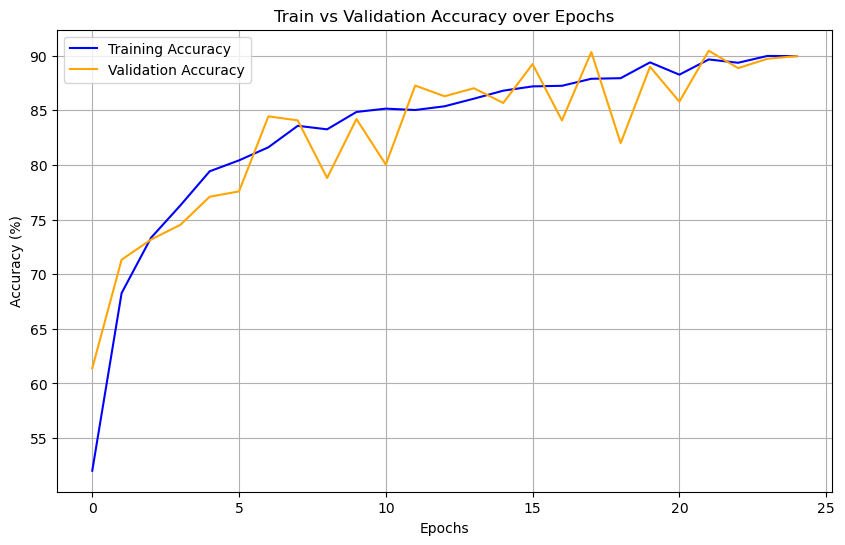

In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from timm import create_model
import numpy as np
from sklearn.metrics import matthews_corrcoef
from matplotlib import pyplot as plt

# Constants
DATASET_PATH = "kvasir-dataset-v2"  # Replace with your dataset path
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
LR = 0.001
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data Augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Dataset
dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

# Dataset Split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.66, random_state=42)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define Hybrid Model: InceptionV3 + Swin Transformer
class HybridInceptionSwin(nn.Module):
    def __init__(self, num_classes):
        super(HybridInceptionSwin, self).__init__()
        self.inception = create_model('inception_v3', pretrained=True, num_classes=num_classes)
        self.swin = create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)
        self.fc = nn.Sequential(
            nn.Linear(2 * num_classes, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        inception_features = self.inception(x)
        swin_features = self.swin(x)
        combined_features = torch.cat((inception_features, swin_features), dim=1)
        return self.fc(combined_features)

# Initialize Model
InceptionSwin = HybridInceptionSwin(num_classes)
InceptionSwin.to(DEVICE)

# Loss Function (Class-Balanced Loss)
class ClassBalancedLoss(nn.Module):
    def __init__(self, beta, num_classes):
        super(ClassBalancedLoss, self).__init__()
        self.beta = beta
        self.num_classes = num_classes
        

    def forward(self, logits, labels):
        class_counts = np.bincount(labels.cpu().numpy(), minlength=self.num_classes)
        effective_num = 1.0 - np.power(self.beta, class_counts)
        weights = (1.0 - self.beta) / (effective_num + 1e-8)
        weights = weights / np.sum(weights)  # Normalize weights
        weights = torch.tensor(weights, dtype=torch.float32).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return loss

loss_fn = ClassBalancedLoss(beta=0.999, num_classes=num_classes)
optimizer = optim.AdamW(InceptionSwin.parameters(), lr=LR)

# Training Function
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

# Validation Function
def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    mcc = matthews_corrcoef(labels_list, preds_list)
    return total_loss / len(loader), 100.0 * correct / total, mcc

# Training Loop
best_mcc = 0
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}
for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(InceptionSwin, train_loader, optimizer, loss_fn, DEVICE)
    val_loss, val_acc, val_mcc = validate_epoch(InceptionSwin, val_loader, loss_fn, DEVICE)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val MCC: {val_mcc:.4f}")

    # Save the best model
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    if val_mcc > best_mcc:
        best_mcc = val_mcc
        torch.save(InceptionSwin.state_dict(), "best_inception_swin_model.pth")
        print(f"Best model saved with MCC: {val_mcc:.4f}")

# Test the Model
InceptionSwin.load_state_dict(torch.load("best_inception_swin_model.pth"))
test_loss, test_acc, test_mcc = validate_epoch(InceptionSwin, test_loader, loss_fn, DEVICE)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, Test MCC: {test_mcc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(history["train_acc"], label="Training Accuracy", color='blue')
plt.plot(history["val_acc"], label="Validation Accuracy", color='orange')
plt.title("Train vs Validation Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

Hybrid Model: RegNet + Swin Transformer

Epoch 1/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.08it/s]


Train Loss: 0.8189, Train Acc: 64.86%
Val Loss: 0.4079, Val Acc: 83.21%, Val MCC: 0.8085
Best model saved with MCC: 0.8085
Epoch 2/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.09it/s]


Train Loss: 0.4455, Train Acc: 80.71%
Val Loss: 0.3988, Val Acc: 85.54%, Val MCC: 0.8361
Best model saved with MCC: 0.8361
Epoch 3/25


...

Train Loss: 0.1044, Train Acc: 95.29%
Val Loss: 0.2396, Val Acc: 92.28%, Val MCC: 0.9120
Best model saved with MCC: 0.9120
Epoch 25/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.09it/s]
C:\Users\Wall-E\AppData\Local\Temp\ipykernel_20060\4093598499.py:156: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

Train Loss: 0.0965, Train Acc: 95.45%
Val Loss: 0.3599, Val Acc: 90.81%, Val MCC: 0.8965


Validation: 100%|██████████| 99/99 [00:33<00:00,  2.96it/s]

Test Loss: 0.1927, Test Acc: 92.30%, Test MCC: 0.9122


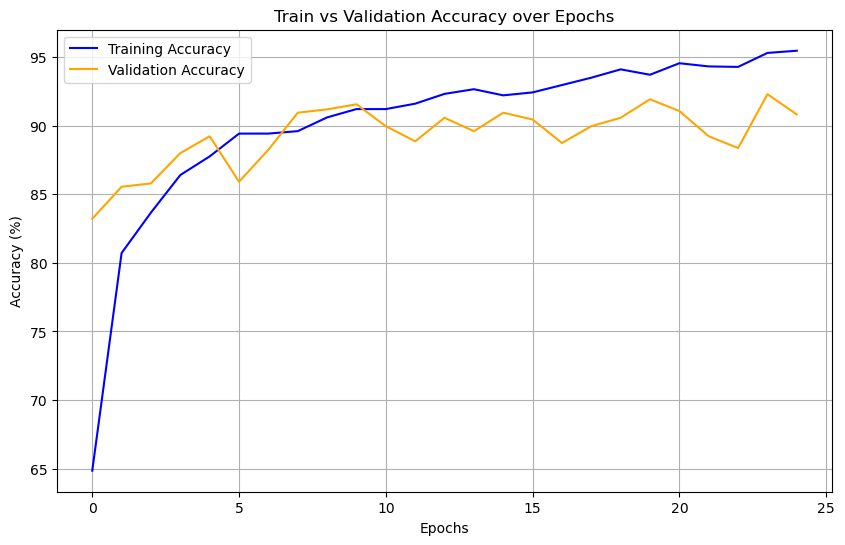

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from timm import create_model
import numpy as np
from sklearn.metrics import matthews_corrcoef
from matplotlib import pyplot as plt

# Constants RegNetSwin
DATASET_PATH = "kvasir-dataset-v2"  # Replace with your dataset path
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
LR = 0.001
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data Augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Dataset
dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

# Dataset Split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.66, random_state=42)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define Hybrid Model: RegNet + Swin Transformer
class HybridRegNetSwin(nn.Module):
    def __init__(self, num_classes):
        super(HybridRegNetSwin, self).__init__()
        self.regnet = create_model('regnety_032', pretrained=True, num_classes=num_classes)
        self.swin = create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)
        self.fc = nn.Sequential(
            nn.Linear(2 * num_classes, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        regnet_features = self.regnet(x)
        swin_features = self.swin(x)
        combined_features = torch.cat((regnet_features, swin_features), dim=1)
        return self.fc(combined_features)


# Initialize Model
RegNetSwin = HybridRegNetSwin(num_classes)
RegNetSwin.to(DEVICE)

# Loss Function (Class-Balanced Loss)
class ClassBalancedLoss(nn.Module):
    def __init__(self, beta, num_classes):
        super(ClassBalancedLoss, self).__init__()
        self.beta = beta
        self.num_classes = num_classes

    def forward(self, logits, labels):
        class_counts = np.bincount(labels.cpu().numpy(), minlength=self.num_classes)
        effective_num = 1.0 - np.power(self.beta, class_counts)
        weights = (1.0 - self.beta) / (effective_num + 1e-8)
        weights = weights / np.sum(weights)  # Normalize weights
        weights = torch.tensor(weights, dtype=torch.float32).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return loss

loss_fn = ClassBalancedLoss(beta=0.999, num_classes=num_classes)
optimizer = optim.AdamW(RegNetSwin.parameters(), lr=LR)

# Training Function
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

# Validation Function
def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    mcc = matthews_corrcoef(labels_list, preds_list)
    return total_loss / len(loader), 100.0 * correct / total, mcc

# Training Loop
best_mcc = 0
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}
for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(RegNetSwin, train_loader, optimizer, loss_fn, DEVICE)
    val_loss, val_acc, val_mcc = validate_epoch(RegNetSwin, val_loader, loss_fn, DEVICE)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val MCC: {val_mcc:.4f}")

    # Save the best model
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    if val_mcc > best_mcc:
        best_mcc = val_mcc
        torch.save(RegNetSwin.state_dict(), "best_regnet_swin_model.pth")
        print(f"Best model saved with MCC: {val_mcc:.4f}")

# Test the Model
RegNetSwin.load_state_dict(torch.load("best_regnet_swin_model.pth"))
test_loss, test_acc, test_mcc = validate_epoch(RegNetSwin, test_loader, loss_fn, DEVICE)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, Test MCC: {test_mcc:.4f}")
plt.figure(figsize=(10, 6))
plt.plot(history["train_acc"], label="Training Accuracy", color='blue')
plt.plot(history["val_acc"], label="Validation Accuracy", color='orange')
plt.title("Train vs Validation Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

Hybrid Model: MobileNetV2 + Swin Transformer

Epoch 1/25


Validation: 100%|██████████| 51/51 [00:15<00:00,  3.20it/s]


Train Loss: 0.7036, Train Acc: 71.96%
Val Loss: 0.5299, Val Acc: 82.60%, Val MCC: 0.8029
Best model saved with MCC: 0.8029
Epoch 2/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.15it/s]


Train Loss: 0.4078, Train Acc: 83.14%
Val Loss: 0.3284, Val Acc: 87.38%, Val MCC: 0.8573
Best model saved with MCC: 0.8573
Epoch 3/25


...

Train Loss: 0.1458, Train Acc: 93.84%
Val Loss: 0.3272, Val Acc: 87.25%, Val MCC: 0.8558
Epoch 25/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.15it/s]
C:\Users\Wall-E\AppData\Local\Temp\ipykernel_20060\3838622952.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

Train Loss: 0.1476, Train Acc: 93.29%
Val Loss: 0.2482, Val Acc: 91.30%, Val MCC: 0.9016


Validation: 100%|██████████| 99/99 [00:32<00:00,  3.00it/s]

Test Loss: 0.2164, Test Acc: 91.73%, Test MCC: 0.9056


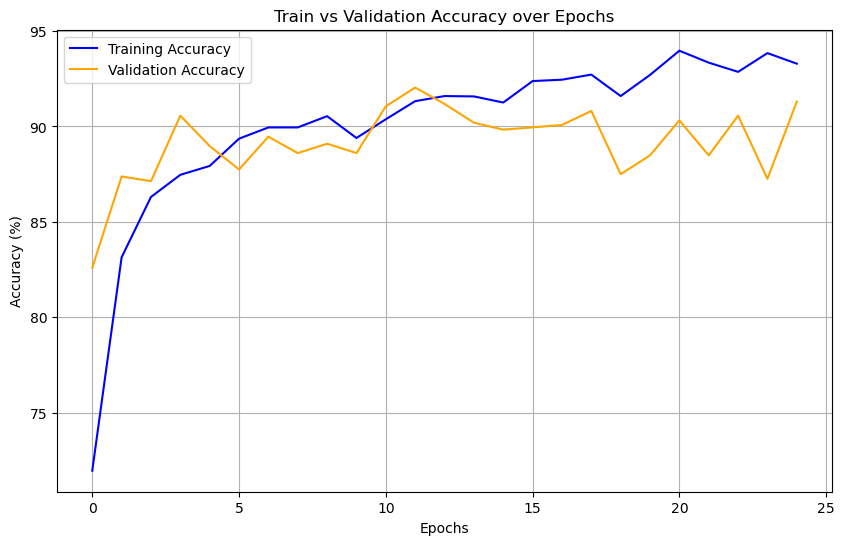

In [7]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from timm import create_model
import numpy as np
from sklearn.metrics import matthews_corrcoef
from matplotlib import pyplot as plt


# Constants
DATASET_PATH = "kvasir-dataset-v2"  # Replace with your dataset path
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
LR = 0.001
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# Data Augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Dataset
dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

# Dataset Split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.66, random_state=42)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define Hybrid Model: MobileNetV2 + Swin Transformer
class HybridMobileNetV2Swin(nn.Module):
    def __init__(self, num_classes):
        super(HybridMobileNetV2Swin, self).__init__()
        self.mobilenetv2 = create_model('mobilenetv2_100', pretrained=True, num_classes=num_classes)
        self.swin = create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)
        self.fc = nn.Sequential(
            nn.Linear(2 * num_classes, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        mobilenetv2_features = self.mobilenetv2(x)
        swin_features = self.swin(x)
        combined_features = torch.cat((mobilenetv2_features, swin_features), dim=1)
        return self.fc(combined_features)

# Initialize Model
MobileNetV2Swin = HybridMobileNetV2Swin(num_classes)
MobileNetV2Swin.to(DEVICE)

# Loss Function (Class-Balanced Loss)
class ClassBalancedLoss(nn.Module):
    def __init__(self, beta, num_classes):
        super(ClassBalancedLoss, self).__init__()
        self.beta = beta
        self.num_classes = num_classes

    def forward(self, logits, labels):
        class_counts = np.bincount(labels.cpu().numpy(), minlength=self.num_classes)
        effective_num = 1.0 - np.power(self.beta, class_counts)
        weights = (1.0 - self.beta) / (effective_num + 1e-8)
        weights = weights / np.sum(weights)  # Normalize weights
        weights = torch.tensor(weights, dtype=torch.float32).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return loss

loss_fn = ClassBalancedLoss(beta=0.999, num_classes=num_classes)
optimizer = optim.AdamW(MobileNetV2Swin.parameters(), lr=LR)

# Training Function
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

# Validation Function
def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    mcc = matthews_corrcoef(labels_list, preds_list)
    return total_loss / len(loader), 100.0 * correct / total, mcc

# Training Loop
best_mcc = 0
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}
for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(MobileNetV2Swin, train_loader, optimizer, loss_fn, DEVICE)
    val_loss, val_acc, val_mcc = validate_epoch(MobileNetV2Swin, val_loader, loss_fn, DEVICE)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val MCC: {val_mcc:.4f}")

    # Save the best model
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    if val_mcc > best_mcc:
        best_mcc = val_mcc
        torch.save(MobileNetV2Swin.state_dict(), "best_mobilenetv2_swin_model.pth")
        print(f"Best model saved with MCC: {val_mcc:.4f}")

# Test the Model
MobileNetV2Swin.load_state_dict(torch.load("best_mobilenetv2_swin_model.pth"))
test_loss, test_acc, test_mcc = validate_epoch(MobileNetV2Swin, test_loader, loss_fn, DEVICE)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, Test MCC: {test_mcc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(history["train_acc"], label="Training Accuracy", color='blue')
plt.plot(history["val_acc"], label="Validation Accuracy", color='orange')
plt.title("Train vs Validation Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

Choosing the best Model

In [8]:
import numpy as np
from collections import Counter
from torch.utils.data import DataLoader
#from model_definitions import DenseNetSwin, ResNetSwin, InceptionSwin, RegNetSwin, MobileNetV2Swin
# Assuming the other models are implemented similarly to HybridSwinResNet
models = [DenseNetSwin, ResNetSwin, InceptionSwin, RegNetSwin, MobileNetV2Swin]  # Replace with your actual model objects

def get_model_predictions(model, dataloader, device):
    """
    Get predictions for all images in the test dataloader using a given model.
    """
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, _ in dataloader:  # Labels are not needed for prediction
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)  # Get class predictions
            predictions.extend(preds.cpu().numpy())
    return predictions

def majority_vote(all_predictions):
    """
    Perform majority voting across predictions from all models for each image.
    """
    final_predictions = []
    for preds in zip(*all_predictions):  # Iterate through predictions for each image
        vote = Counter(preds).most_common(1)[0][0]  # Get the class with the highest votes
        final_predictions.append(vote)
    return np.array(final_predictions)

# Test the models and perform majority voting
def evaluate_with_voting(models, test_dataloader, device):
    """
    Evaluate the test dataset using all models and perform majority voting for final predictions.
    """
    # Collect predictions from all models
    all_model_predictions = []
    for model in models:
        predictions = get_model_predictions(model, test_dataloader, device)
        all_model_predictions.append(predictions)

    # Perform majority voting
    final_predictions = majority_vote(all_model_predictions)
    return all_model_predictions, final_predictions

# Test DataLoader
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Evaluate models and perform voting
all_model_predictions, final_predictions = evaluate_with_voting(models, test_dataloader, DEVICE)

# Display results for each test image
for i, (image, _) in enumerate(test_dataset):  # Assuming test_dataset is an instance of Subset
    print(f"Image {i+1}:")
    for model_idx, predictions in enumerate(all_model_predictions):
        print(f"  Model {model_idx + 1} prediction: Class {predictions[i]}")
    print(f"  Final voted class: Class {final_predictions[i]}")

Image 1:
  Model 1 prediction: Class 2
  Model 2 prediction: Class 2
  Model 3 prediction: Class 2
  Model 4 prediction: Class 2
  Model 5 prediction: Class 2
  Final voted class: Class 2
Image 2:
  Model 1 prediction: Class 1
  Model 2 prediction: Class 1
  Model 3 prediction: Class 1
  Model 4 prediction: Class 1
  Model 5 prediction: Class 1
  Final voted class: Class 1
Image 3:
  Model 1 prediction: Class 2
  Model 2 prediction: Class 2
  Model 3 prediction: Class 2
  Model 4 prediction: Class 2
  Model 5 prediction: Class 2
  Final voted class: Class 2
Image 4:
  Model 1 prediction: Class 6
  Model 2 prediction: Class 6
  Model 3 prediction: Class 6
  Model 4 prediction: Class 6
  Model 5 prediction: Class 6
  Final voted class: Class 6
Image 5:
  Model 1 prediction: Class 4
  Model 2 prediction: Class 4
  Model 3 prediction: Class 4
  Model 4 prediction: Class 4
  Model 5 prediction: Class 4
  Final voted class: Class 4
Image 6:
  Model 1 prediction: Class 3
  Model 2 prediction:

Confusion matrix

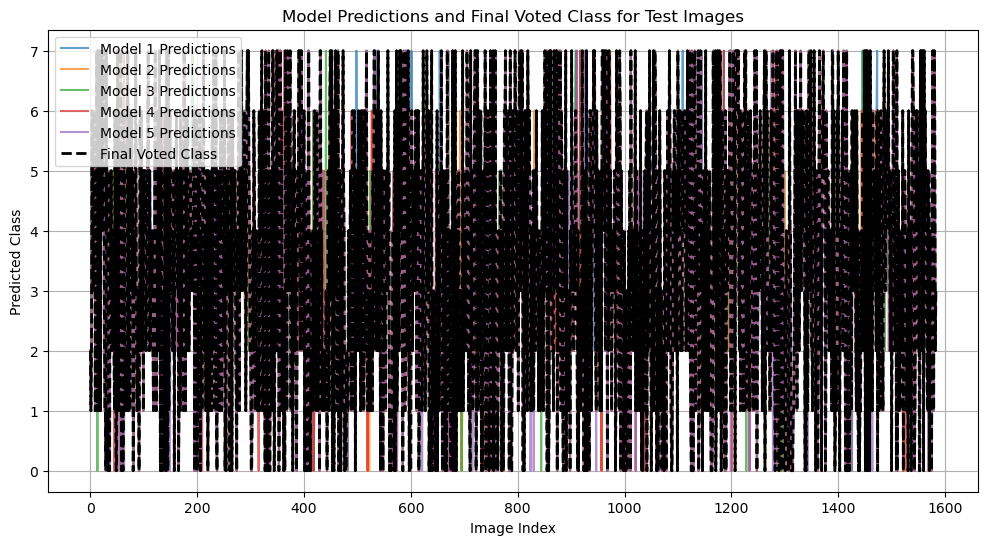

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import DataLoader

# Assuming the other models are implemented similarly to HybridSwinResNet
models = [DenseNetSwin, ResNetSwin, InceptionSwin, RegNetSwin, MobileNetV2Swin]  # Replace with your actual model objects

def get_model_predictions(model, dataloader, device):
    """
    Get predictions for all images in the test dataloader using a given model.
    """
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, _ in dataloader:  # Labels are not needed for prediction
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)  # Get class predictions
            predictions.extend(preds.cpu().numpy())
    return predictions

def majority_vote(all_predictions):
    """
    Perform majority voting across predictions from all models for each image.
    """
    final_predictions = []
    for preds in zip(*all_predictions):  # Iterate through predictions for each image
        vote = Counter(preds).most_common(1)[0][0]  # Get the class with the highest votes
        final_predictions.append(vote)
    return np.array(final_predictions)

def evaluate_with_voting(models, test_dataloader, device):
    """
    Evaluate the test dataset using all models and perform majority voting for final predictions.
    """
    # Collect predictions from all models
    all_model_predictions = []
    for model in models:
        predictions = get_model_predictions(model, test_dataloader, device)
        all_model_predictions.append(predictions)

    # Perform majority voting
    final_predictions = majority_vote(all_model_predictions)
    return all_model_predictions, final_predictions

# Graph visualization
def plot_results(all_model_predictions, final_predictions, test_dataset):
    """
    Plot a graph showing predictions from each model and the final voting results.
    """
    num_images = len(test_dataset)
    x = np.arange(num_images)  # Image indices

    plt.figure(figsize=(12, 6))

    # Plot predictions from each model
    for i, model_predictions in enumerate(all_model_predictions):
        plt.plot(x, model_predictions, label=f"Model {i + 1} Predictions", alpha=0.7)

    # Plot final voting results
    plt.plot(x, final_predictions, label="Final Voted Class", linewidth=2, linestyle='--', color='black')

    plt.xlabel("Image Index")
    plt.ylabel("Predicted Class")
    plt.title("Model Predictions and Final Voted Class for Test Images")
    plt.legend()
    plt.grid(True)
    plt.show()

# Test DataLoader
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Evaluate models and perform voting
all_model_predictions, final_predictions = evaluate_with_voting(models, test_dataloader, DEVICE)

# Plot the results
plot_results(all_model_predictions, final_predictions, test_dataset)

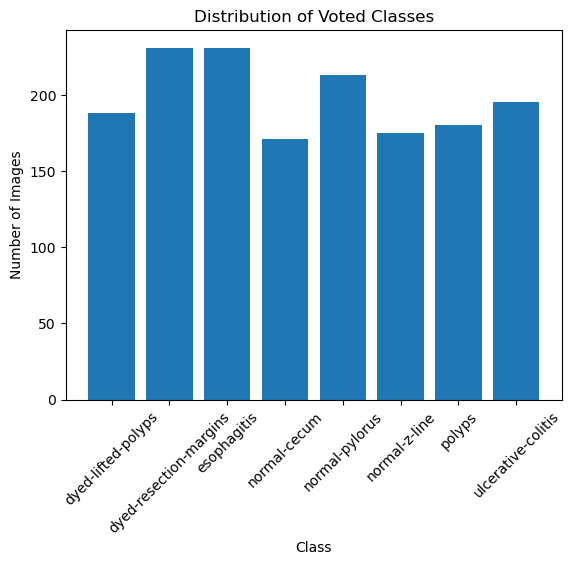

In [10]:
# Modelin test kümesi üzerindeki tahminlerini alın
InceptionSwin.eval()
final_predictions = []
true_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = InceptionSwin(images)
        _, preds = torch.max(outputs, 1)
        final_predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Sınıf isimlerini dataset nesnesinden al
classes = dataset.classes

# Grafik çizimi
def plot_voting_distribution(final_predictions, classes):
    unique, counts = np.unique(final_predictions, return_counts=True)
    plt.bar([classes[i] for i in unique], counts)
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.title("Distribution of Voted Classes")
    plt.xticks(rotation=45)  # Sınıf isimleri çok uzunsa eğimli göstermek için
    plt.show()

plot_voting_distribution(final_predictions, classes)
